# Imports

In [1]:
bool(None)

False

In [1]:
from load_data import MnistDataloader
from ModifiedNEAT.util.storage import STORAGE_DIR
from ModifiedNEAT.util.qol import manage_params
from ModifiedNEAT.util.datetime import clock, eta
from ModifiedNEAT.util.storage import save, load
from ModifiedNEAT.util.fancy_text import CM, Fore

import ModifiedNEAT as meat
import ModifiedNEAT.nn as mnn
import ModifiedNEAT.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import random

from torch import Tensor
from torch.optim import Optimizer
from torch.nn.utils import clip_grad_norm_
from numpy import ndarray as CPUArray
from typing import Union
from copy import deepcopy
from matplotlib.pyplot import Axes

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float32
GENOMES = 100

# Load Data

In [3]:
ABS_PATH = 'D:\PycharmProjects\Modified-NEAT\examples\mnist\mnist_data\\'
loader = MnistDataloader(
    f"{ABS_PATH}train-images.idx3-ubyte",
    f"{ABS_PATH}train-labels.idx1-ubyte",
    f"{ABS_PATH}t10k-images.idx3-ubyte",
    f"{ABS_PATH}t10k-labels.idx1-ubyte",
)
RESIZE = (28, 28)
(train_inp, train_out), (eval_inp, eval_out) = loader.load_data(GENOMES, 100, 1000, resize=(16, 16), rand_rot=False, rand_flip=False, batch_size=128,
                                                                device='cpu', dtype=torch.float32)
train_inp.shape, train_out.shape, eval_inp.shape, eval_out.shape

Loaded 100 records.
Loaded 1000 records.


(torch.Size([100, 100, 1, 16, 16]),
 torch.Size([100, 100]),
 torch.Size([100, 1000, 1, 16, 16]),
 torch.Size([100, 1000]))

In [4]:
def tensor_memory(tensor: Tensor):
    return tensor.numel() * tensor.element_size() / (1024 ** 2)

In [5]:
tensor_memory(eval_inp)

97.65625

In [6]:
train_inp.device, train_inp.dtype, train_inp.device, train_out.dtype

(device(type='cpu'), torch.float32, device(type='cpu'), torch.int64)

In [7]:
torch.max(train_inp)

tensor(0.9961)

In [8]:
IMG_SHAPE = train_inp.shape[3:]
IMG_SHAPE

torch.Size([16, 16])

# View data

In [9]:
def show_image(image: Tensor, title: str = None, size: tuple[int, int] = None, cmap='binary', axis: Axes = None):
    if size is None:
        size = (360, 360)
    if image.ndim == 3:
        image = image.permute(1, 2, 0)
    elif image == 2:
        pass
    else:
        raise ValueError(f"Unsupported ndim")
    image = image.cpu()
    if axis is None:
        _, axis = plt.subplots(1, 1, figsize=(size[0] * 0.01, size[1] * 0.01))
    axis.imshow(image, cmap=cmap)
    if title is not None:
        axis.set_title(title)
    axis.set_axis_off()
    if axis is None:
        plt.show()

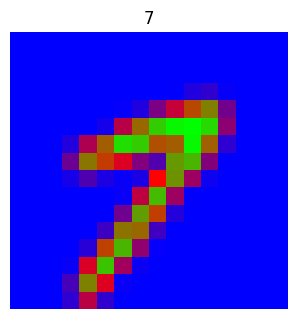

In [10]:
rand_train_idx = np.random.randint(0, len(train_inp))
show_image(train_inp[0, rand_train_idx], train_out[0, rand_train_idx].item(), cmap='brg')

In [11]:
def show_batch(images: Tensor, predictions: Tensor = None, labels: Tensor = None, columns=8,
               size: tuple[int, int] = None, cmap='binary', no_axes=True):
    if size is None:
        size = (720, 1080)
    if images.ndim == 4:
        images = images.permute(0, 2, 3, 1)
    elif images == 3:
        pass
    else:
        raise ValueError(f"Unsupported ndim")

    images = images.cpu()
    rows = math.ceil(len(images) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(size[1] * 0.01, size[0] * 0.01))
    if isinstance(axes, CPUArray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for index, (axis, image) in enumerate(zip(axes, images)):
        axis.imshow(image, cmap=cmap)
        title = ''
        if predictions is not None:
            title += f"P={predictions[index].cpu().item()}"
        if labels is not None:
            title += f"L={labels[index].cpu().item()}"
        if len(title) > 0:
            axis.set_title(title)
        if no_axes:
            axis.set_axis_off()
    plt.show()

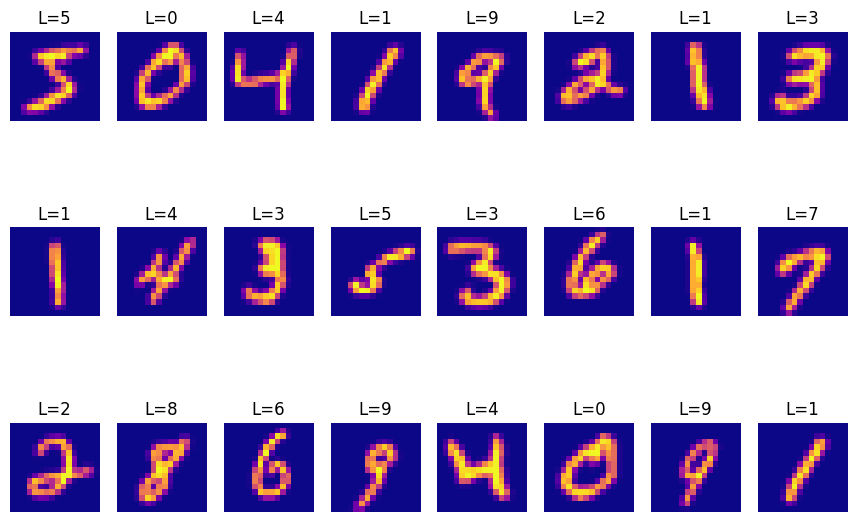

In [12]:
show_batch(train_inp[0, :24], labels=train_out[0, :24], cmap='plasma')

# Model Architecture

In [13]:
class SimpleCNN(meat.NeatModule):
    def __init__(self, inputs: int, outputs: int, dim_size: int, layers: int, kernel_size: int, img_size: tuple[int, int],
                 div=1, actv=nn.SiLU(), bias=False, device='cpu', dtype=torch.float32):
        super().__init__()
        sequence = nn.ModuleList()
        for layer_idx in range(layers+1):
            # size_ = tuple([dim - (kernel_size-1) * layer_idx for dim in img_size])
            if layer_idx < layers:
                sequence.append(
                    mnn.Conv2d(inputs if layer_idx == 0 else dim_size+(dim_size//div*(layer_idx-1)),
                               outputs if layer_idx == layers else dim_size+(dim_size//div*layer_idx),
                               kernel_size=kernel_size, bias=bias, device=device, dtype=dtype,
                               padding=-1, padding_mode='zeros')
                    if layer_idx == 0 else
                    mnn.ResidualBlock(
                        inputs if layer_idx == 0 else dim_size+(dim_size//div*(layer_idx-1)),
                        outputs if layer_idx == layers else dim_size+(dim_size//div*layer_idx),
                        kernel_size=kernel_size, bias=bias, device=device, dtype=dtype,
                        padding=-1, padding_mode='zeros', image_ndim=2, norm_groups=1,
                    )
                )
                if layer_idx == layers-1:
                    sequence.append(
                        mnn.GroupNorm(1, dim_size+(dim_size//div*layer_idx) if layer_idx != layers else outputs,
                                      device=device, dtype=dtype)
                    )
                    sequence.append(actv)
            else:
                sequence.extend([
                    nn.Flatten(-(len(img_size)+1), -1),
                    mnn.Linear((dim_size+(dim_size//div*(layers-1))) * math.prod(img_size),
                               outputs, bias=bias, device=device, dtype=dtype)
                ])
        self.sequence = mnn.Sequential(*sequence)

        # Attributes
        self.inputs     = inputs
        self.outputs    = outputs
        self.dim_size   = dim_size
        self.kernel_size = kernel_size
        self.layers     = layers
        self.div        = div
        self.bias       = bias

        # States
        self.device     = device
        self.dtype      = dtype

    def forward(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        tensor = (tensor - 0.5) * 2.0
        # convolved = False
        # for module in self:
        #     if isinstance(module, mnn.Linear) and not convolved:
        #         tensor = torch.flatten(tensor.permute(0, -1, -2, 1), 1)
        #         convolved = True
        #     tensor = module(tensor)
        # Return the logits
        tensor = self.sequence(tensor, keys=keys)
        return tensor

    def evaluate(self, tensor: Tensor, keys: Union[int, list[int]] = None):
        return torch.argmax(self.forward(tensor, keys), dim=-1)

DyParam = Union[int, list[int]]

class EnsembleCNN(meat.NeatModule):
    def __init__(self, inputs: int, outputs: int, kernel_sizes: DyParam, dim_sizes: DyParam, layers: DyParam,
                 img_size: tuple[int, int], divs: DyParam, actv=nn.SiLU(),
                 bias=False, device='cpu', dtype=torch.float32):
        super(EnsembleCNN, self).__init__()
        if isinstance(kernel_sizes, (int, float)):
            kernel_sizes = [kernel_sizes]

        self.networks: list[SimpleCNN] = nn.ModuleList()
        for k_idx, kernel_size in enumerate(kernel_sizes):
            dim_size    = dim_sizes if isinstance(dim_sizes, (int, float)) else dim_sizes[min(k_idx, len(dim_sizes)-1)]
            layer_num   = layers if isinstance(layers, (int, float)) else layers[min(k_idx, len(layers)-1)]
            div         = divs if isinstance(divs, (int, float)) else divs[min(k_idx, len(divs)-1)]
            self.networks.append(SimpleCNN(
                inputs, outputs, dim_size, layer_num, kernel_size, img_size, div, actv, bias, device, dtype
            ))

        # Attributes
        self.inputs     = inputs
        self.outputs    = outputs
        self.img_size   = img_size
        self.bias       = bias

        # States
        self.device     = device
        self.dtype      = dtype

    def forward(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        summation = []
        for module in self.networks:
            summation.append(module(tensor, keys=keys))
        return torch.sum(torch.stack(summation), dim=0)

    def evaluate(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        return torch.argmax(self.forward(tensor, keys=keys, verbose=verbose), dim=-1)

    def guess(self, tensor, keys: Union[int, list[int]] = None):
        logits = self.forward(tensor, keys=keys)
        dist = torch.distributions.Categorical(F.softmax(logits, -1))
        return dist.sample()

    def save(self, file_no: int = None):
        g_params = f"globals-i{self.inputs}-o{self.outputs}-b{self.bias}-s{self.img_size[0]}_{self.img_size[1]}"
        for network in self.networks:
            name = f"params_{g_params}_locals-d{network.dim_size}-" \
                     f"k{network.kernel_size}-l{network.layers}-d{network.div}"
            params = network.state_dict()
            save(params, name, 'mnist_models', subdirectory=f"{network.__class__.__name__}", file_no=file_no)

    def load(self, file_no: int = None):
        g_params = f"globals-i{self.inputs}-o{self.outputs}-b{self.bias}-s{self.img_size[0]}_{self.img_size[1]}"
        for network in self.networks:
            name = f"params_{g_params}_locals-d{network.dim_size}-" \
                     f"k{network.kernel_size}-l{network.layers}-d{network.div}"
            params = load(name, 'mnist_models', subdirectory=f"{network.__class__.__name__}", file_no=file_no)
            if params is not None:
                network.load_state_dict(params)

In [14]:
test_inputs = torch.randn(1, 3, 1, *IMG_SHAPE, dtype=DTYPE)
# CHANNELS = (
#     [32 + 16 * max(0, 4*n-1) for n in range(3)],
# )
CHANNELS_LAYERS = (3,)
test_model = EnsembleCNN(
    inputs=1, outputs=10, kernel_sizes=(3,), dim_sizes=16,
    layers=CHANNELS_LAYERS,
    img_size=IMG_SHAPE, divs=2, actv=nn.Tanh(),
    bias=True, device='cpu', dtype=DTYPE
)
print(test_model)
with torch.no_grad():
    test_outputs = test_model.evaluate(test_inputs, verbose=2)
    # test_model.save()
    # test_model.load()
test_outputs, test_outputs.shape

EnsembleCNN(
  (networks): ModuleList(
    (0): SimpleCNN(
      (sequence): Sequential[NeatModule](
        (0): Conv2d[NeatModule](channels_in=1, channels_out=16, kernel_size=(3, 3), stride=1, padding=(1, 1), dilation=1, groups=1, bias=True, padding_mode=constant)
        (1): ResidualBlock(16, 24, kernel_size=3, pad=-1, pad_mode=zeros, bias=True, ng=1, actv=SiLU)
        (2): ResidualBlock(24, 32, kernel_size=3, pad=-1, pad_mode=zeros, bias=True, ng=1, actv=SiLU)
        (3): GroupNorm[NeatModule](groups=1, channels=32, eps=1e-06, affine=True, bias=True)
        (4): Tanh()
        (5): Flatten(start_dim=-3, end_dim=-1)
        (6): Linear[NeatModule](inputs=8192, outputs=10, bias=True)
      )
    )
  )
)


(tensor([[0, 9, 0]]), torch.Size([1, 3]))

# Create Model

In [15]:
def model_size(model: meat.NeatModule):
    return np.sum([param.numel() * param.element_size() for param in model.parameters()]) / (1024 ** 2)

In [16]:
def model_params(model: meat.NeatModule):
    return np.sum([param.numel() for param in model.parameters()])

In [17]:
INPUT_DIMS = 1
OUTPUT_DIMS = 10
DIM_SIZE = 8
DEPTH = 4
LAYERS = 2
BIAS = True

In [18]:
# MODEL = ResNet(
#     1, DIM_SIZE, 10, kernel_size=3, depth=(DEPTH, LAYERS),
#     kernel_size_init=7, stride=2, padding=1, padding_mode='circular', fc_size=1024,
#     dropout=0.0, pri_actv=nn.SiLU(), sec_actv=None, bias=BIAS, device=DEVICE, dtype=DTYPE
# )
# MODEL = EnsembleCNN(
#     inputs=1, outputs=10, kernel_sizes=(3,), dim_sizes=(32,),
#     layers=(10,), img_size=RESIZE, divs=(2,),
#     norm=nn.BatchNorm2d, actv=nn.SiLU, bias=False, device=DEVICE, dtype=DTYPE,
# )
# CHANNELS = (
#     [16 for n in range(1)],
#     # [64 + 32 * n for n in range(3)],
#     # [32 + 32 * max(0, 2*n-1) for n in range(2)],
# )
CHANNELS = [DIM_SIZE for _ in range(1)]
CHANNELS_LAYERS = (LAYERS,)
MODEL = EnsembleCNN(
    inputs=INPUT_DIMS, outputs=OUTPUT_DIMS, kernel_sizes=(3,),
    dim_sizes=CHANNELS, layers=CHANNELS_LAYERS, img_size=IMG_SHAPE, divs=2,
    bias=BIAS, device=DEVICE, dtype=DTYPE, actv=nn.SiLU()
)
with torch.no_grad():
    for param in MODEL.parameters():
        if param.ndim >= 2:
            nn.init.kaiming_normal_(param)
        else:
            param[:] = torch.rand_like(param)
MODEL

EnsembleCNN(
  (networks): ModuleList(
    (0): SimpleCNN(
      (sequence): Sequential[NeatModule](
        (0): Conv2d[NeatModule](channels_in=1, channels_out=8, kernel_size=(3, 3), stride=1, padding=(1, 1), dilation=1, groups=1, bias=True, padding_mode=constant)
        (1): ResidualBlock(8, 12, kernel_size=3, pad=-1, pad_mode=zeros, bias=True, ng=1, actv=SiLU)
        (2): GroupNorm[NeatModule](groups=1, channels=12, eps=1e-06, affine=True, bias=True)
        (3): SiLU()
        (4): Flatten(start_dim=-3, end_dim=-1)
        (5): Linear[NeatModule](inputs=3072, outputs=10, bias=True)
      )
    )
  )
)

# Create Population

In [19]:
CONFIG = meat.Config('mnist')

In [20]:
CONFIG.genome.init_type             = 'normal'
CONFIG.genome.weight_init_mean      = 0
CONFIG.genome.weight_init_std       = np.pi
CONFIG.genome.weight_min_value      = -np.inf
CONFIG.genome.weight_max_value      = np.inf
CONFIG.genome.weight_mutate_power   = 0.8
CONFIG.genome.weight_mutate_rate    = 0.80
CONFIG.genome.weight_mutate_rate    = 0.15
CONFIG.reproduction.min_species_size = GENOMES
CONFIG.reproduction.purge           = 1
CONFIG.reproduction.survival_threshold = 0.05
CONFIG.reproduction.elitism         = 10
CONFIG.species.compatibility_threshold = np.inf
CONFIG.stagnation.max_stagnation    = 1
CONFIG.stagnation.species_elitism   = 1
CONFIG.save()
CONFIG.load(2)

Created configuration 'GENERAL CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'GENOME CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'SPECIES CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'STAGNATION CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'REPRODUCTION CONFIG' in NEAT Configuration mnist-neat_config.txt
fitness_criterion         = max
fitness_threshold         = inf
pop_size                  = 100
reset_on_extinction       = True
seed                      = 94
Loaded configuration 'GENERAL CONFIG' in NEAT Configuration mnist-neat_config.txt
weight_init_mean          = 0
weight_init_std           = 3.141592653589793
weight_max_value          = inf
weight_min_value          = -inf
weight_mutate_power       = 0.8
weight_mutate_rate        = 0.15
weight_replace_rate       = 0.05
bias_init_mean            = 0.0
bias_init_std             = 1.0
bias_max_value            = inf
b

In [21]:
POPULATION = meat.Population(GENOMES, MODEL, CONFIG, init_reporter=True)

C:\Python3.11\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 75 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
C:\Python3.11\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 50 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))



Initialized genomes in  in 0.4s

Ran distance kernel in 0.43 s

Created distances cache in 2.06 s
Collected species representatives in 3.25 s
Filled species in 1.99 s
Updated species mapping in 1.06 s
Completed speciating in 8.37 s
Mean genetic distance 1.815, standard deviation 1.346, with 1 species


In [22]:
f"{model_size(MODEL):.3f}", f"{model_params(MODEL):.2e}"

('12.652', '3.32e+06')

In [38]:
SCHEDULERS = [
    optim.scheduler.CosineAnnealing(CONFIG, 10, 0.5, 'weight_mutate_power', True, True),
    optim.scheduler.CosineAnnealing(CONFIG, 10, 0.5, 'weight_mutate_rate', True, True),
    optim.scheduler.CosineAnnealing(CONFIG, 10, 2, 'weight_replace_rate', True, True),
]

In [24]:
# MODEL.save(file_no=None)

In [25]:
MODEL.load(file_no=None)

Successfully loaded  save file from 'D:\PycharmProjects\Modified-NEAT\storage\mnist_models\SimpleCNN\params_globals-i1-o10-bTrue-s16_16_locals-d8-k3-l2-d2-2.pkl'.


# Train

In [26]:
def cross_entropy_loss(logits: Tensor, targets: Tensor):
    # logits shape (genomes, batch_size, logits), targets shape (genomes, batch_size)
    # Compute log-softmax along the last dimension (num_classes)

    log_probs = F.log_softmax(logits, dim=-1)
    # Gather the log probabilities of the correct class
    losses = -log_probs.gather(dim=-1, index=targets.unsqueeze(-1)).squeeze(-1)

    # Compute mean loss per genome (reduce over batch_size dimension)
    losses = losses.mean(dim=-1)  # Shape: (genomes,)

    # losses shape (genomes,)
    return losses

In [27]:
test_classes = 10
test_tensor_targ = torch.randint(0, test_classes, (100, 3))
test_tensor_logt = torch.normal(0, 1e1, (100, 64, 10))
# test_tensor_logt = F.one_hot(test_tensor_targ, test_classes).float()
test_losses = torch.log10(cross_entropy_loss(test_tensor_logt, test_tensor_targ))
test_losses.mean(), test_losses.std()
# , test_tensor_targ[:5], test_tensor_logt[:5]

(tensor(1.1202), tensor(0.2238))

In [28]:
MODEL(eval_inp[:, :10].to(DEVICE)).shape

torch.Size([100, 10, 10])

In [29]:
def get_batches(records: int, batch_size: int = None, shuffle=False):
    if batch_size is None:
        batch_size = records
    assert records > 0
    if batch_size is None:
        batch_size = records
    else:
        assert batch_size > 0
        batch_size = min(batch_size, records)

    indices: list[int] = list(range(records))
    if shuffle:
        random.shuffle(indices)
    batch_indices: list[list[int]] = list()
    batch: list[int] = list()
    for i, index in enumerate(indices):
        batch.append(index)
        batch_is_filled = len(batch) == batch_size
        no_more_records = i == len(indices) - 1 and not batch_is_filled
        if batch_is_filled or no_more_records:
            batch_indices.append(batch)
            batch = list()

    return batch_indices

In [30]:
BATCH_SIZE = 64

In [31]:
def get_accuracy(model: meat.NeatModule, inputs, outputs, batch_size: int, guess=False, verbose=False,
                 keys: Union[int, list[int]] = None, mean=False):
    if keys is not None and not isinstance(keys, (tuple, list)):
        keys = [keys]
    if keys is not None:
        mapping = POPULATION.get_mapping()
        key_indices = [mapping[key] for key in keys]
        inputs, outputs = inputs[key_indices], outputs[key_indices]

    torch.cuda.empty_cache()
    batch_indices = get_batches(inputs.shape[1], batch_size, True)
    summation = {index: 0 for index in range(len(outputs))}
    elements = {index: 0 for index in range(len(outputs))}
    # print(inputs.shape, outputs.shape, len(batch_indices), max([len(batch) for batch in batch_indices]))
    ts = clock.perf_counter()
    for step, batch in enumerate(batch_indices):
        with torch.no_grad():
            images = inputs[:, batch].to(model.device)
            target: Tensor = outputs[:, batch].to(model.device)
            if not guess:
                prediction: torch.Tensor = model.evaluate(images, keys=keys)
            else:
                prediction: torch.Tensor = model.guess(images, keys=keys)
            total = prediction == target
            for index, (sub_total, sub_target) in enumerate(zip(total, target)):
                summation[index] += sub_total.sum().item()
                elements[index] += sub_target.numel()
        if verbose:
            eta(ts, step+1, len(batch_indices), f"Getting accuracy")
    if verbose:
        print(f"\nCalculated accuracy in {clock.perf_counter()-ts:.2f}s")

    accuracy = {index: s / e for (index, s), e in zip(summation.items(), elements.values())}
    torch.cuda.empty_cache()
    if not mean:
        return np.max(list(accuracy.values())).item()
    else:
        return np.mean(list(accuracy.values())).item()
MODEL.eval();

In [32]:
get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, verbose=True)

Getting accuracy: progress=100% eta=0sec
Calculated accuracy in 0.85s


0.344

In [33]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE))*100

(52.0, 65.60000000000001)

In [34]:
from torchvision import transforms

In [35]:
def evaluate(population: meat.Population, **options):
    global train_inp, train_out
    if MODEL.genome_num != train_inp.shape[0]:
        # train_inp, train_out = create(linear.genome_num)
        pass

    # -------------------- Fetching -------------------- #
    losses_plot: list[float] = options['losses']
    accuracy_plot: list[float] = options['accuracies']
    rand_rotate: float = None

    # -------------------- Evaluating -------------------- #
    records = train_inp.shape[1]
    losses = torch.zeros(len(population.genomes), device=DEVICE, dtype=DTYPE)
    batches = get_batches(records, BATCH_SIZE, shuffle=True)
    for step, batch in enumerate(batches):
        inputs = train_inp[:, batch].to(MODEL.device)
        if rand_rotate is not None:
            inputs = transforms.RandomRotation((-rand_rotate, rand_rotate))(input)
        targets = train_out[:, batch].to(MODEL.device)
        predictions = MODEL(inputs)
        batch_losses = cross_entropy_loss(predictions, targets)
        losses += batch_losses
    losses /= len(batches)

    # -------------------- Setting scores -------------------- #
    scores = -losses.cpu().numpy()
    best_key = list(population.genomes.keys())[0]
    best_score = scores[0]
    for score, gid in zip(scores, population.genomes.keys()):
        population.genomes[gid].fitness = score
        if score > best_score:
            best_score = score
            best_key = best_key

    # -------------------- Logging -------------------- #
    losses_plot.append(losses.min().cpu().item())
    accuracy_plot.append(get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, keys=best_key))

In [36]:
# def train(model: meat.NeatModule, optimizer: Optimizer, epochs: int, batch_size: int, show: tuple[int, int] = True,
#           checkpoints=1, acc_step: int = None, save_best=False, clip: float = None, max_div: float = None,
#           scheduler: optim.lr_scheduler.LRScheduler = None, train_dataset: tuple[Tensor, Tensor] = None, rot: int = None):
#     torch.cuda.empty_cache()
#     if train_dataset is None:
#         inputs, outputs = train_inp, train_out
#     else:
#         inputs, outputs = train_dataset
#
#     batch_indices_train = get_batches(outputs.shape[0], batch_size)
#     batch_indices_eval = get_batches(eval_out.shape[0], batch_size)
#     losses_train = []
#     losses_eval = []
#     train_accuracies = []
#     eval_accuracies = []
#     ts, ud, ut = clock.perf_counter(), 0, epochs * len(batch_indices_train)
#
#     best_loss = 0
#     model.eval()
#     with torch.no_grad():
#         for batch_eval in batch_indices_eval:
#             best_loss += F.nll_loss(model(eval_inp[batch_eval]), eval_out[batch_eval], reduction='sum')
#         if acc_step is not None:
#             ta = get_accuracy(model, inputs, outputs, batch_size)
#             ea = get_accuracy(model, eval_inp, eval_out, batch_size)
#             train_accuracies.append(ta)
#             eval_accuracies.append(ea)
#         optimizer.zero_grad()
#     best_loss /= len(batch_indices_eval)
#     prev_loss = best_loss
#
#     best_epoch = -1
#     model.train()
#     save_state = deepcopy(model.state_dict())
#     for epoch in range(epochs):
#         try:
#             model.train()
#             train_loss = 0
#             for batch_idx, batch_train in enumerate(batch_indices_train):
#                 input = inputs[batch_train]
#                 if rot is not None:
#                     input = transforms.RandomRotation((-rot, rot))(input)
#                 prediction = model(input)
#                 target = outputs[batch_train]
#                 loss = F.nll_loss(prediction, target)
#                 loss.backward()
#                 if clip is not None:
#                     clip_grad_norm_(model.parameters(), clip)
#                 optimizer.step()
#                 optimizer.zero_grad()
#
#                 with torch.no_grad():
#                     train_loss += F.nll_loss(prediction, target, reduction='sum')
#
#                 ud += 1
#                 eta(ts, ud, ut, f"training | loss={prev_loss.cpu().item(): .4e} | "
#                                 f"best={best_loss.cpu().item(): .4e} | "
#                                 f"step={best_epoch}")
#             train_loss / len(batch_indices_train)
#
#             model.eval()
#             eval_loss = 0
#             with torch.no_grad():
#                 for batch_idx, batch_eval in enumerate(batch_indices_eval):
#                     loss = F.nll_loss(model(eval_inp[batch_eval]), eval_out[batch_eval], reduction='sum')
#                     eval_loss += loss
#             eval_loss /= len(batch_indices_eval)
#             prev_loss = eval_loss
#
#             if epoch % checkpoints == 0 and eval_loss < best_loss:
#                 best_loss = eval_loss
#                 save_state = deepcopy(model.state_dict())
#                 best_epoch = epoch
#
#             losses_train.append(train_loss.cpu().item())
#             losses_eval.append(eval_loss.cpu().item())
#
#             if acc_step is not None and (epoch+1) % acc_step == 0:
#                 with torch.no_grad():
#                     ta = get_accuracy(model, inputs, outputs, batch_size)
#                     ea = get_accuracy(model, eval_inp, eval_out, batch_size)
#                     train_accuracies.append(ta)
#                     eval_accuracies.append(ea)
#                     if max_div is not None and ta > ea+max_div:
#                         break
#
#             if scheduler is not None:
#                 scheduler.step()
#         except KeyboardInterrupt:
#             break
#
#     if save_best:
#         model.load_state_dict(save_state)
#     print(f"\nFinished training in {round(clock.perf_counter()-ts)}s")
#
#     if show is None or show is True:
#         show = (1440, 480)
#     elif show is False:
#         show = None
#     if show is not None:
#         fig, axes = plt.subplots(1, 2 if acc_step else 1, figsize=[s*0.01 for s in show])
#         if isinstance(axes, CPUArray):
#             axes = axes.flatten()
#         else:
#             axes = [axes]
#         axes[0].plot(np.log10(losses_train), label='train')
#         axes[0].plot(np.log10(losses_eval), label='eval')
#         axes[0].set_title(f"Loss")
#         axes[0].legend()
#         if acc_step is not None:
#             axes[1].plot(train_accuracies)
#             axes[1].plot(eval_accuracies)
#             axes[1].set_title(f'Accuracy')
#         plt.show()
#
#     model.eval()
#     torch.cuda.empty_cache()
def train(epochs: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    losses: list[float] = []
    accuracies: list[float] = []

    ts = clock.perf_counter()
    for scheduler in SCHEDULERS:
        scheduler.reset()
    try:
        for epoch in range(epochs):
            POPULATION.run(evaluate, 1,
                           losses=losses, accuracies=accuracies,
                           verbose=3 if epoch==0 else False)
            for scheduler in SCHEDULERS:
                scheduler.step()
            eta(ts, epoch+1, epochs, f"NEAT training")
    except KeyboardInterrupt as e:
        print(e)
    except (RuntimeError, StopIteration, ValueError) as e:
        print(e)
    print(f"finished NEAT training in {clock.perf_counter() - ts:.1f}s")

    # attention.causal_mask = True
    if show:
        plt.close()
        axes = plt.subplots(1, 2, figsize=(14.4, 5.4))[1]
        axes = axes.flatten()
        axes[0].plot(np.log10(losses))
        axes[0].set_title('Loss')
        axes[1].plot(accuracies)
        axes[1].set_title('Accuracy')

    torch.cuda.empty_cache()
    return losses


 ****** Running generation 1 ****** 

executing fitness function <function evaluate at 0x0000016763FF93A0> on population, skip-enabled=False
------ Updating population ------

Population's average fitness: -56.90187 std_dev: 103.61099
Best fitness: -1.67803 - species 1 - id 0
Average adjusted fitness: 0.882


C:\Python3.11\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 75 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
C:\Python3.11\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 75 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
C:\Python3.11\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 50 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))



Spawned new genomes in  in 4.86s

Ran distance kernel in 0.26 s

Created distances cache in 0.26 s
Collected species representatives in 0.13 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.39 s
Mean genetic distance 0.264, standard deviation 0.330, with 1 species
Population of 100 members in 1 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
   1    0   100     -1.7    0.882     0
Total extinctions: 0
Generation time: 11.973 sec
NEAT training: progress=100% eta=0secfinished NEAT training in 133.0s


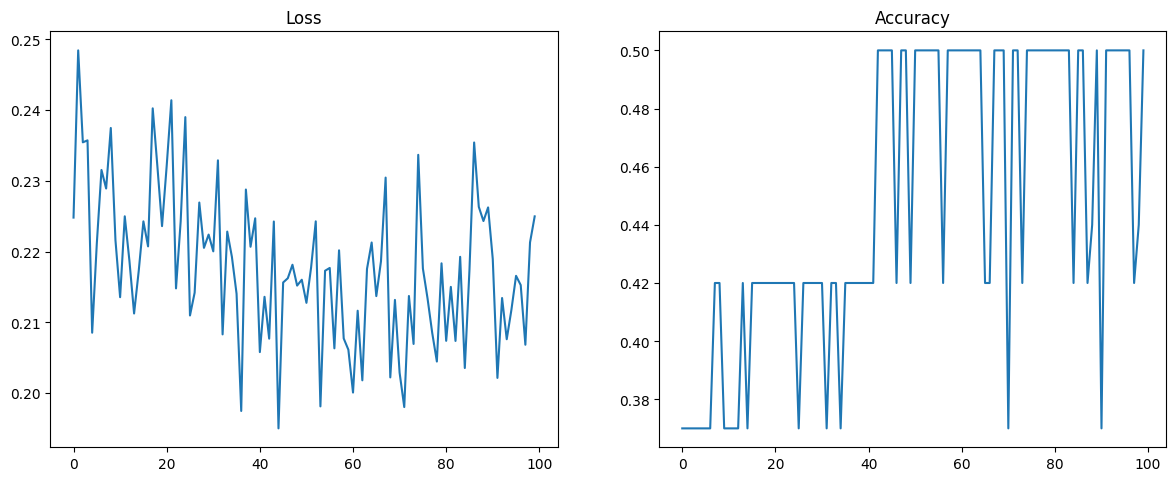

In [37]:
neat_losses = train(100)


 ****** Running generation 101 ****** 

executing fitness function <function evaluate at 0x0000016763FF93A0> on population, skip-enabled=False
------ Updating population ------

Population's average fitness: -133.51542 std_dev: 152.96798
Best fitness: -1.58454 - species 1 - id 3713
Average adjusted fitness: 0.766

Spawned new genomes in  in 1.78s

Ran distance kernel in 0.28 s

Created distances cache in 0.28 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.28 s
Mean genetic distance 0.358, standard deviation 0.443, with 1 species
Population of 100 members in 1 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
   1  100   100     -1.6    0.766    56
Total extinctions: 0
Generation time: 3.081 sec (7.527 average)
NEAT training: progress=100% eta=0secfinished NEAT training in 121.8s


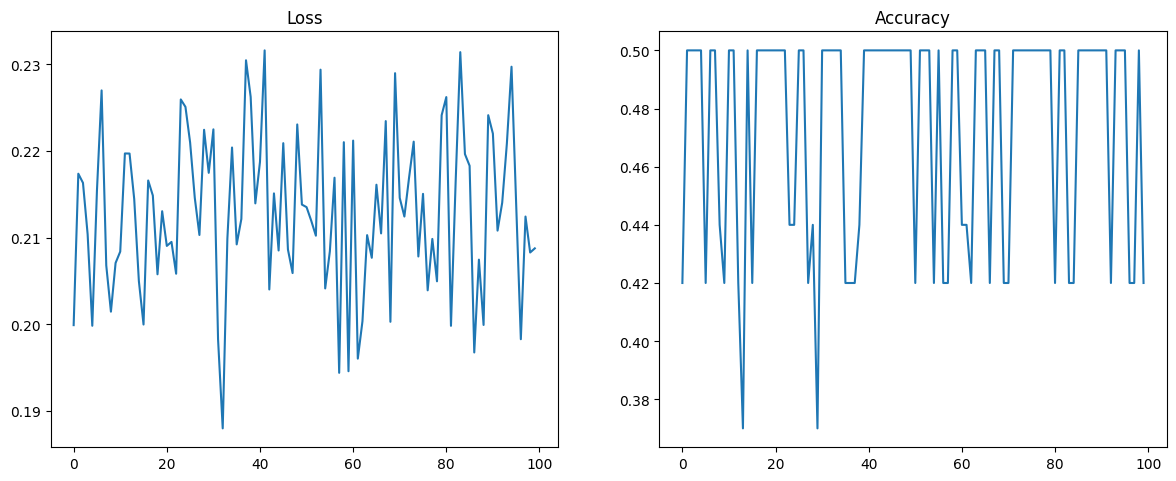

In [39]:
neat_losses2 = train(100)

In [40]:
MODEL.eval();

# Evaluate

In [41]:
(1-get_accuracy(MODEL, train_inp, train_out, 64, guess=True, mean=True))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, 64, guess=True, mean=True))*100

(81.08, 84.385)

In [42]:
(1-get_accuracy(MODEL, train_inp, train_out, 128, keys=POPULATION.best_genome.key))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, 128, keys=POPULATION.best_genome.key))*100

(60.0, 71.6)

In [47]:
(1-get_accuracy(MODEL, train_inp, train_out, 128, guess=True, keys=POPULATION.best_genome.key))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, 128, guess=True, keys=POPULATION.best_genome.key))*100

(60.0, 76.2)

In [61]:
def get_indices(images: Tensor, labels: Tensor, include: Union[int, list[int]] = None,
                faulty: int = False, correct: int = False, shuffle=True,
                keys: Union[int, list[int]] = None):
    if isinstance(include, (int, float)):
        include = [include]
    if keys and not isinstance(keys, (tuple, list)):
        keys = [keys]
    error_indices = []
    mapping = POPULATION.get_mapping()
    indices = list(range(len(images))) if not keys else [mapping[key] for key in keys]
    images, labels = images[indices], labels[indices]
    if faulty:
        if isinstance(faulty, bool):
            faulty = 64
        with torch.no_grad():
            for batch in get_batches(labels.shape[1], faulty, False):
                pred = MODEL.evaluate(images[:, batch].to(MODEL.device), keys=keys)
                for index, errored in zip(batch, pred!=labels[:, batch].to(MODEL.device)):
                    if torch.any(errored):
                        error_indices.append(index)
        print(f"Found {len(error_indices)} record predictions with errors")
    valid_indices = []
    if correct:
        if isinstance(correct, bool):
            correct = 64
        with torch.no_grad():
            for batch in get_batches(labels.shape[1], correct, False):
                pred = MODEL.evaluate(images[:, batch].to(MODEL.device), keys=keys)
                for index, correct in zip(batch, pred==labels[:, batch].to(MODEL.device)):
                    if torch.any(correct):
                        valid_indices.append(index)
        print(f"Found {len(valid_indices)} valid record predictions ")
    indices_filtered = []
    for g_labels in labels.cpu():
        for x, record in enumerate(g_labels.cpu().tolist()):
            record_needed = include is None or record in include
            spec_type = x in error_indices or x in valid_indices
            no_type = not correct and not faulty
            if record_needed and (spec_type or no_type):
                indices_filtered.append(x)
    indices_filtered = list(set(indices_filtered))
    if shuffle:
        random.shuffle(indices_filtered)
    if len(indices_filtered) > 0:
        return indices_filtered
    else:
        raise ValueError(f"No indices available")

In [62]:
test_records = 24
MODEL.eval();

In [63]:
train_indices = get_indices(train_inp, train_out, faulty=None, keys=POPULATION.best_genome.key)
len(train_indices)

6000

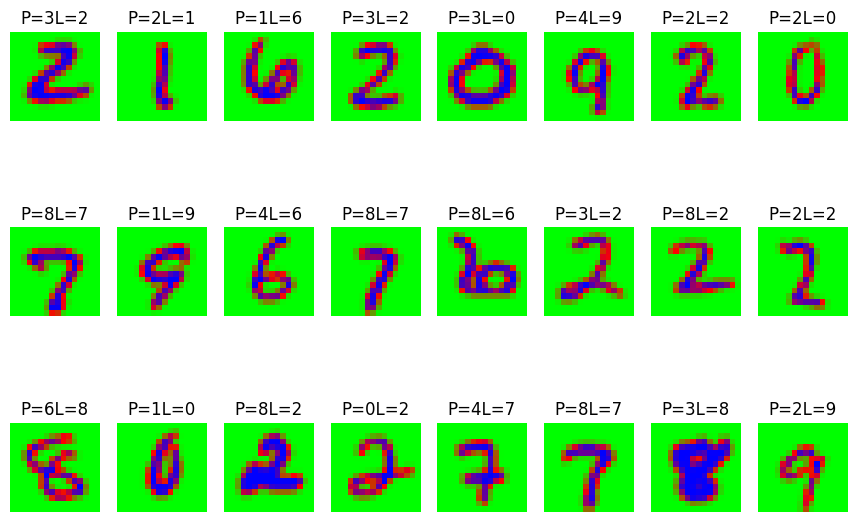

In [64]:
with torch.no_grad():
    random.shuffle(train_indices)
    test_indices = train_indices[:test_records]
    test_labels = MODEL.guess(train_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(train_inp[0, test_indices], test_labels[0], train_out[0, test_indices], cmap='brg_r')

In [65]:
eval_indices = get_indices(eval_inp, eval_out, faulty=256, correct=False)
len(eval_indices)

Found 400 record predictions with errors


400

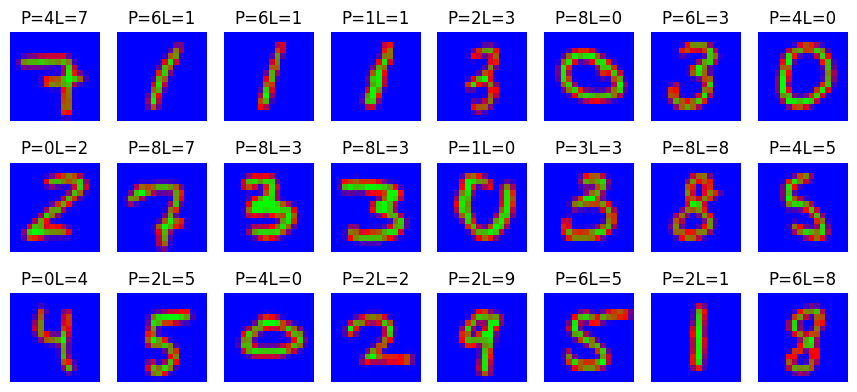

In [67]:
with torch.no_grad():
    random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.evaluate(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

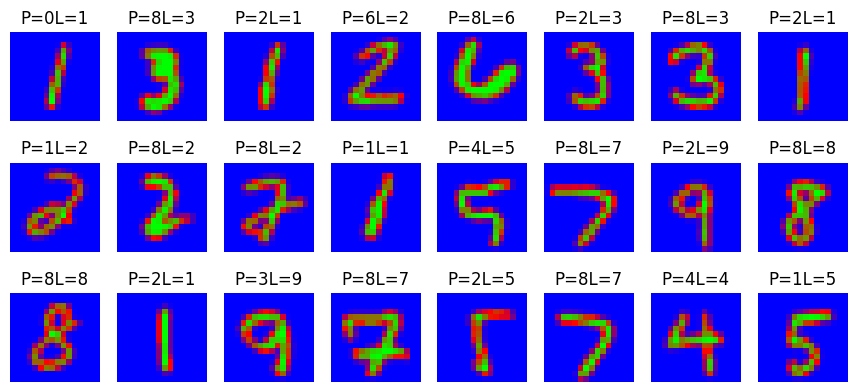

In [68]:
with torch.no_grad():
    random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.guess(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

# PyTorch training

In [106]:
def train2(epochs: int, batch_size: int, key: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    MODEL.requires_grad_(True)
    # attention.causal_mask = False
    optimizer = torch.optim.AdamW(MODEL.parameters(), 1e-3)

    losses = []
    acc_train, acc_eval = [], []
    ts, ud, ut = clock.perf_counter(), 0, epochs

    # ------------------------------ Training Data ------------------------------ #
    index = POPULATION.get_mapping()[key]
    inputs, outputs = train_inp[index].unsqueeze(0).to(MODEL.device), train_out[index].unsqueeze(0).to(MODEL.device)
    print(inputs.shape, outputs.shape)

    best_loss = torch.inf
    best_epoch = -1
    save_state = MODEL.state_dict()
    batches = get_batches(inputs.shape[1], batch_size, True)
    for epoch in range(epochs):
        try:
            loss: Tensor = 0
            for batch in batches:
                # if epoch == 0:
                #     print(inputs.shape, outputs.shape)
                inp = inputs[:, batch].to(MODEL.device)
                out = outputs[0, batch].to(MODEL.device)
                predictions = MODEL(inp, keys=key).squeeze(0)
                # if epoch == 0:
                #     print(inp.shape, predictions.shape, out.shape)
                batch_loss = F.cross_entropy(predictions, out)
                batch_loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                loss += batch_loss
            loss /= len(batches)

            losses.append(loss.cpu().item())
            acc_train.append(get_accuracy(MODEL, train_inp, train_out, batch_size, True, keys=key))
            acc_eval.append(get_accuracy(MODEL, eval_inp, eval_out, batch_size, True, keys=key))

            if epoch % checkpoints == 0 and loss < best_loss:
                best_loss = loss
                save_state = MODEL.state_dict()
                best_epoch = epoch

            ud += 1
            eta(ts, ud, ut, f"training | loss={loss.cpu().item():.4e} | "
                            f"best={best_loss.cpu().item():.4e} | "
                            f"epoch={best_epoch}")
        except KeyboardInterrupt:
            break
    print(f"\nFinished training in {clock.perf_counter() - ts:.2f}s")

    MODEL.load_state_dict(save_state)

    # attention.causal_mask = True
    if show:
        plt.close()
        axes = plt.subplots(1, 2, figsize=(10.8, 5.4))[1]
        axes = axes.flatten()
        axes[0].plot(np.log10(losses))
        axes[0].set_title('Loss')
        axes[1].plot(acc_train, label='train')
        axes[1].plot(acc_eval, label='eval')
        axes[1].legend()
        axes[1].set_title('Accuracy')

    MODEL.requires_grad_(False)
    torch.cuda.empty_cache()
    return losses

torch.Size([1, 6000, 1, 16, 16]) torch.Size([1, 6000])
training | loss=1.6584e-01 | best=1.6584e-01 | epoch=299: progress=100% eta=0secc
Finished training in 231.62s


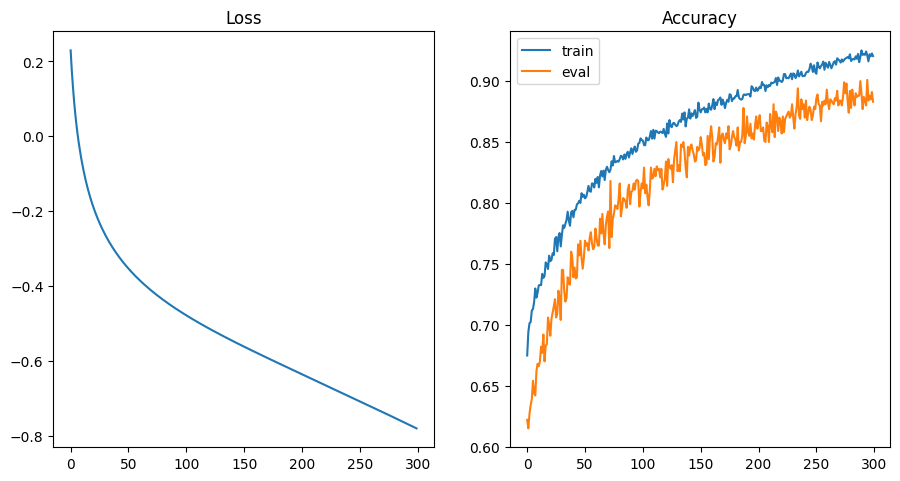

In [102]:
train_losses = train2(100, 256, POPULATION.best_genome.key, checkpoints=1)

In [104]:
extra_key = list(POPULATION.genomes.keys())[1]
extra_key

1868

torch.Size([1, 6000, 1, 16, 16]) torch.Size([1, 6000])
training | loss=2.9743e-01 | best=2.9743e-01 | epoch=299: progress=100% eta=0secc
Finished training in 227.46s


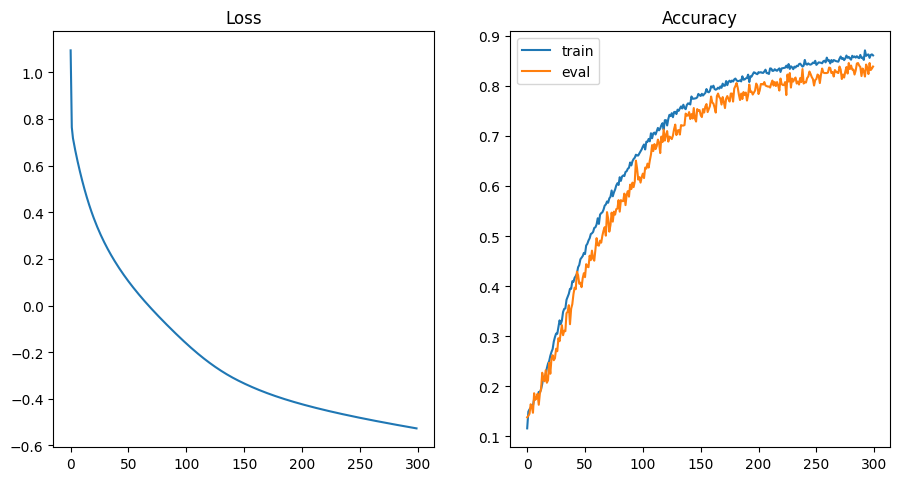

In [105]:
train2(300, 256, extra_key, checkpoints=1);

In [107]:
extra_key2 = list(POPULATION.genomes.keys())[3]
extra_key2

1652

torch.Size([1, 6000, 1, 16, 16]) torch.Size([1, 6000])
training | loss=1.6699e-01 | best=1.6699e-01 | epoch=299: progress=100% eta=0secc
Finished training in 170.28s


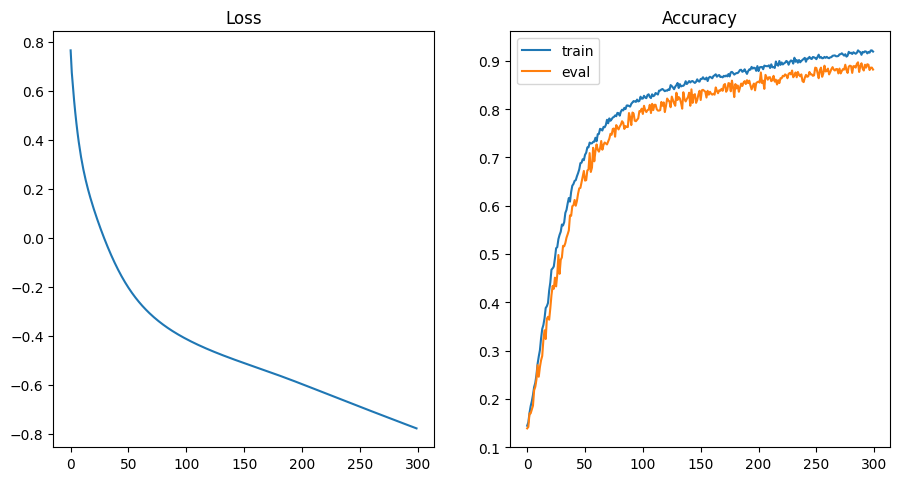

In [108]:
train2(300, 256, extra_key2, checkpoints=1);

In [109]:
(1 - get_accuracy(MODEL, train_inp, train_out, 128, keys=POPULATION.best_genome.key)) * 100, \
(1 - get_accuracy(MODEL, eval_inp, eval_out, 128, keys=POPULATION.best_genome.key)) * 100

(8.819999999999995, 12.1)

In [110]:
(1 - get_accuracy(MODEL, train_inp, train_out, 128, guess=True, keys=POPULATION.best_genome.key)) * 100, \
(1 - get_accuracy(MODEL, eval_inp, eval_out, 128, guess=True, keys=POPULATION.best_genome.key)) * 100

(11.799999999999999, 15.800000000000002)

In [111]:
train_indices = get_indices(train_inp, train_out, faulty=None, keys=POPULATION.best_genome.key)

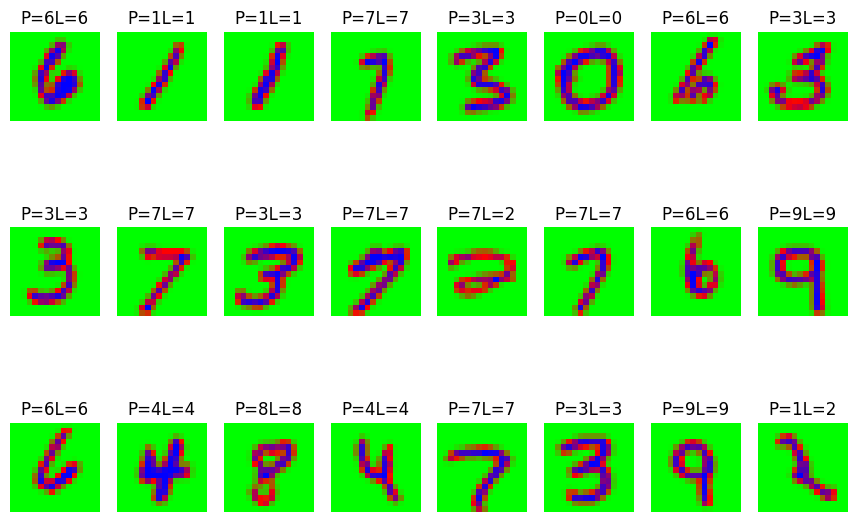

In [113]:
with torch.no_grad():
    random.shuffle(train_indices)
    test_indices = train_indices[:test_records]
    test_labels = MODEL.guess(train_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(train_inp[0, test_indices], test_labels[0], train_out[0, test_indices], cmap='brg_r')

In [114]:
eval_indices = get_indices(eval_inp, eval_out, faulty=256, correct=False)
len(eval_indices)

Found 400 record predictions with errors


400

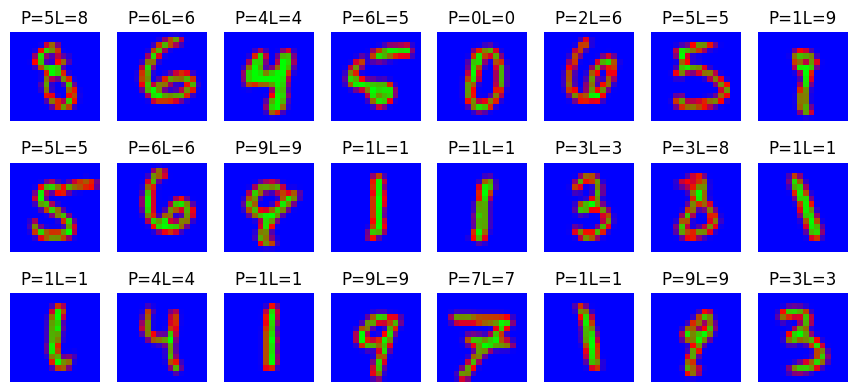

In [115]:
with torch.no_grad():
    random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.evaluate(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

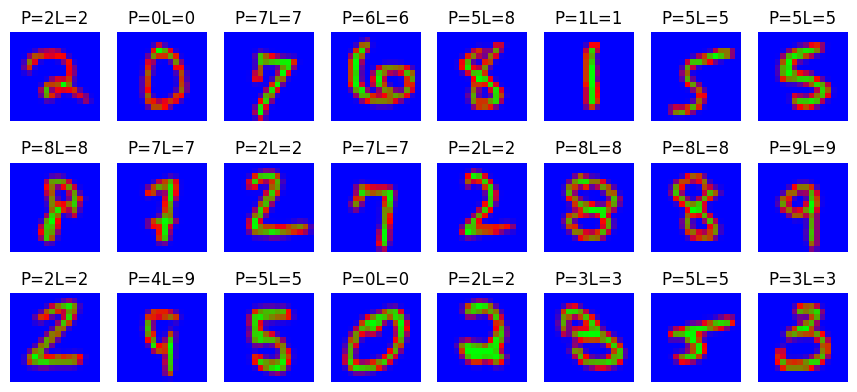

In [140]:
with torch.no_grad():
    # random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.guess(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

# Evaluate on diffusion generated data

In [ ]:
from diffusion_proj.models.simple import UNet
from diffusion_proj.diffusion import Diffusion

In [ ]:
SEED = 100
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
diffusion = Diffusion(1e-3, 6e-1, timesteps=100)

NO_DISPLAY_IMAGES = 100
with torch.no_grad():
    test_image = train_inp[0]
    torch_image_batch = torch.stack([test_image] * NO_DISPLAY_IMAGES)
    test_timesteps = torch.linspace(0, diffusion.timesteps - 1, NO_DISPLAY_IMAGES).long()
    noisy_image_batch, _ = diffusion.forward(torch_image_batch, test_timesteps, DEVICE)
    show_batch(noisy_image_batch, columns=10, cmap=plt.cm.brg)

In [ ]:
gen_model = UNet(
    1, 3, sequence_channels=[16 + 16 * n for n in range(5)], time_embeddings=diffusion.timesteps,
    label_embeddings=100, bias=False,
    layers=3, kernel_size_init=7, padding_mode='zeros', device=DEVICE, dtype=DTYPE
)

In [ ]:
IMG_SIZE = (64, 64)

In [ ]:
gen_model.load()

In [ ]:
# torch.cuda.empty_cache()
NUM_CLASSES = 10
NUM_DISPLAY_IMAGES = 10
for c in range(NUM_CLASSES):
    # imgs = torch.normal(MEAN, STD * 1., (NUM_DISPLAY_IMAGES, 1) + IMAGE_SHAPE).to(DEVICE)
    imgs = torch.randn(NUM_DISPLAY_IMAGES, 1, *IMG_SIZE).to(DEVICE)
    with torch.no_grad():
        fetch_ts = clock.perf_counter()
        labels = torch.full((NUM_DISPLAY_IMAGES,), c, device=DEVICE, dtype=torch.long)
        for i in reversed(range(diffusion.timesteps)):
            t = torch.full((1,), i, dtype=torch.long, device=DEVICE)
            # print(imgs.shape, labels.shape, t.shape)
            imgs = diffusion.backward(x=imgs, t=t, model=gen_model, labels=labels)
            eta(fetch_ts, diffusion.timesteps-i, diffusion.timesteps, f"Fetching {c+1}")
    print(imgs.shape)
    plt.close()
    show_batch(imgs, labels=torch.full((NUM_DISPLAY_IMAGES,), c), columns=NUM_DISPLAY_IMAGES, cmap='brg')
    plt.show()

plt.show()

In [ ]:
def create_data(records: int, batch_size: int, shuffle=True):
    torch.cuda.empty_cache()
    inputs, outputs = [], []
    ts, ud, ut = clock.perf_counter(), 0, math.ceil(records / batch_size) * 10 * diffusion.timesteps
    try:
        for number in range(10):
            inp, out = [], []
            for batch_idx in range(math.ceil(records / batch_size)):
                # Generate the image from noise
                with torch.no_grad():
                    batch_images = torch.randn(batch_size, 1, *IMG_SIZE).to(DEVICE, DTYPE)
                    batch_labels = torch.full((batch_size,), number, device=DEVICE, dtype=torch.long)
                    for t_step in reversed(range(diffusion.timesteps)):
                        batch_timestep = torch.full((1,), t_step, dtype=torch.long, device=DEVICE)
                        batch_images = diffusion.backward(x=batch_images, t=batch_timestep, model=gen_model, labels=batch_labels)
                        # Estimate time
                        ud += 1
                        eta(ts, ud, ut, f"Creating data from diffusion")
                # Append images
                inp.append(batch_images)
                out.append(batch_labels)
            # Concatenate batches and crop then append
            inp, out = torch.cat(inp)[:records], torch.cat(out)[:records]
            inputs.append(inp)
            outputs.append(out)
    except KeyboardInterrupt:
        torch.cuda.empty_cache()
        return None
    # Concat all numbers
    inputs, outputs = torch.cat(inputs), torch.cat(outputs)
    # Shuffle if required
    if shuffle:
        indices = list(range(len(inputs)))
        random.shuffle(indices)
        inputs, outputs = inputs[indices], outputs[indices]
    print(f"\nCompleted data creation of {len(outputs)} records in {round(clock.perf_counter()-ts)}s")
    torch.cuda.empty_cache()
    return transforms.Resize(train_inp.shape[-2:])(inputs), outputs

def normalize_data(inputs: Tensor):
    maximum, minimum = torch.max(inputs), torch.min(inputs)
    return (inputs - minimum) / (maximum - minimum)

In [ ]:
# diff_inp, diff_out = create_data(6000, 1024, True)
# diff_inp = normalize_data(diff_inp)

In [ ]:
def save_data(dataset: tuple[Tensor, Tensor], file_no: int = None, name="data",
              dir='diffusion', sub_dir='training_data', save_path: str = None):
    save(dataset, file_no=file_no, filename=name, directory=dir, subdirectory=sub_dir, save_location=save_path)

def load_data(file_no: int = None, name="data",  dir='diffusion', sub_dir='training_data',
              save_path: str = None) -> Union[tuple[Tensor, Tensor], None]:
    dataset = load(file_no=file_no, filename=name, directory=dir, subdirectory=sub_dir, save_location=save_path)
    if dataset is not None:
        return dataset
    else:
        raise ValueError(f"No dataset found in storage location")

In [ ]:
# save_data((diff_inp, diff_out), file_no=None)

In [ ]:
diff_inp, diff_out = load_data(file_no=None)

In [ ]:
diff_inp.shape, diff_out.shape

In [ ]:
show_batch(diff_inp[:32], labels=diff_out[:32], columns=8, cmap=plt.cm.brg)

In [ ]:
with torch.no_grad():
    show_batch(diff_inp[:32], predictions=MODEL.evaluate(diff_inp[:32]),
               labels=diff_out[:32], columns=8, cmap=plt.cm.brg)

In [ ]:
(1-get_accuracy(MODEL, diff_inp, diff_out, 256))*100, (1-get_accuracy(MODEL, diff_inp, diff_out, 256, guess=True))*100

In [ ]:
diff_indices = get_indices(diff_inp, diff_out, faulty=256)[:40]

In [ ]:
with torch.no_grad():
    random.shuffle(diff_indices)
    diff_eval_indices = diff_indices[:40]
    show_batch(diff_inp[diff_eval_indices], predictions=MODEL.evaluate(diff_inp[diff_eval_indices]),
               labels=diff_out[diff_eval_indices], columns=8, cmap=plt.cm.winter)

In [ ]:
with torch.no_grad():
    show_batch(diff_inp[diff_eval_indices], predictions=MODEL.guess(diff_inp[diff_eval_indices]),
               labels=diff_out[diff_eval_indices], columns=8, cmap=plt.cm.winter)

In [ ]:
train(MODEL, OPTIMIZER, 50, 128, acc_step=5, clip=0.5, scheduler=None, save_best=False,
      # train_dataset=(torch.cat([diff_inp, train_inp]), torch.cat([diff_out, train_out])),
      train_dataset=(diff_inp, diff_out),
      rot=10,
      )

In [ ]:
(1-get_accuracy(MODEL, diff_inp, diff_out, 128))*100, (1-get_accuracy(MODEL, diff_inp, diff_out, 128, guess=True))*100